In [5]:
from pathlib import Path
from references import references
from bamboo_hh_new.utils.analysis_config import AnalysisConfig

import mplhep
import numpy as np
import matplotlib.pyplot as plt

In [6]:
%config InlineBackend.figure_format = 'retina'

In [7]:
plt.style.use(mplhep.style.CMS)
label_fontsize = 18
tick_fontsize = 18
rlabel = "13.6 TeV"
legend_fontsize = 18
cms_fontsize = 18

In [8]:
def hist_to_numpy(hist):
    values = np.array([hist.GetBinContent(i + 1) for i in range(hist.GetNbinsX())])
    edges = np.array([hist.GetBinLowEdge(i + 1) for i in range(hist.GetNbinsX() + 1)])
    return values, edges

def plot_signal_background(normalized_signal, normalized_background):
    ylabel = "normalized events"
    rlabel = "13.6 TeV"

    sig_vals, edges = hist_to_numpy(normalized_signal)
    bkg_vals, _ = hist_to_numpy(normalized_background)

    fig, ax = plt.subplots(figsize=(6.5, 6))  # Square-ish

    ax.step(edges[:-1], sig_vals, where='post', color='blue', linewidth=2.0, label="Signal")
    ax.fill_between(edges[:-1], sig_vals, step='post', color='blue', alpha=0.2)

    ax.step(edges[:-1], bkg_vals, where='post', color='red', linewidth=2.0, label="Background")
    ax.fill_between(edges[:-1], bkg_vals, step='post', color='red', alpha=0.2)

    ax.set_xlabel(r"$m_{bb}$ (GeV)", fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, max(sig_vals.max(), bkg_vals.max()) * 1.2)
    ax.grid(True)

    ax.legend(fontsize=legend_fontsize, loc="upper right", frameon=True)

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(
        1.0, 1.0, rlabel,
        transform=ax.transAxes,
        fontsize=cms_fontsize,
        horizontalalignment='right',
        verticalalignment='bottom'
    )

    fig.tight_layout()
    plt.show()

In [9]:
import json

def load_lr_mapping(json_path: str, name: str):
    with open(json_path, "r") as f:
        data = json.load(f)

    for corr in data["corrections"]:
        if corr["name"] == name:
            edges = np.array(corr["data"]["edges"])
            values = np.array(corr["data"]["content"])
            return edges, values
    raise ValueError(f"Mapping '{name}' not found in file.")

def plot_lr(ratio_hist, mapping_path, corr_name, take_log:bool):

    ratio_vals, edges = hist_to_numpy(ratio_hist)
    if take_log:
        lr_vals = np.log(ratio_vals)
    else:
        lr_vals = ratio_vals
    
    # Load the mapping
    mapping_edges, mapping_vals = load_lr_mapping(mapping_path, corr_name)

    fig, ax = plt.subplots(figsize=(6.5, 6))

    # Histogram-based LLR
    ax.step(
        edges[:-1],
        lr_vals,
        where='post',
        color='green',
        linewidth=2.0,
        alpha=0.7,
        label='Binned LLR'
    )
    # Mapping-based LLR
    ax.step(
        mapping_edges[:-1],
        mapping_vals,
        where='post',
        color='purple',
        linestyle='-',
        linewidth=2.5,
        alpha=0.6,
        label='Interpolated LLR'
    )
    ax.set_xlabel(r"$m_{bb}$ (GeV)", fontsize=label_fontsize)
    ax.set_ylabel(r"LLR$(m_{bb})$", fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(0, 300)
    ax.grid(True)

    ax.legend(fontsize=legend_fontsize, loc='lower right', frameon=True)

    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(
        1.0, 1.0, rlabel,
        transform=ax.transAxes,
        fontsize=cms_fontsize,
        horizontalalignment='right',
        verticalalignment='bottom'
    )

    fig.tight_layout()
    plt.show()


### Refactoring_Reference/JetTop_even_test_from_RC

From branches


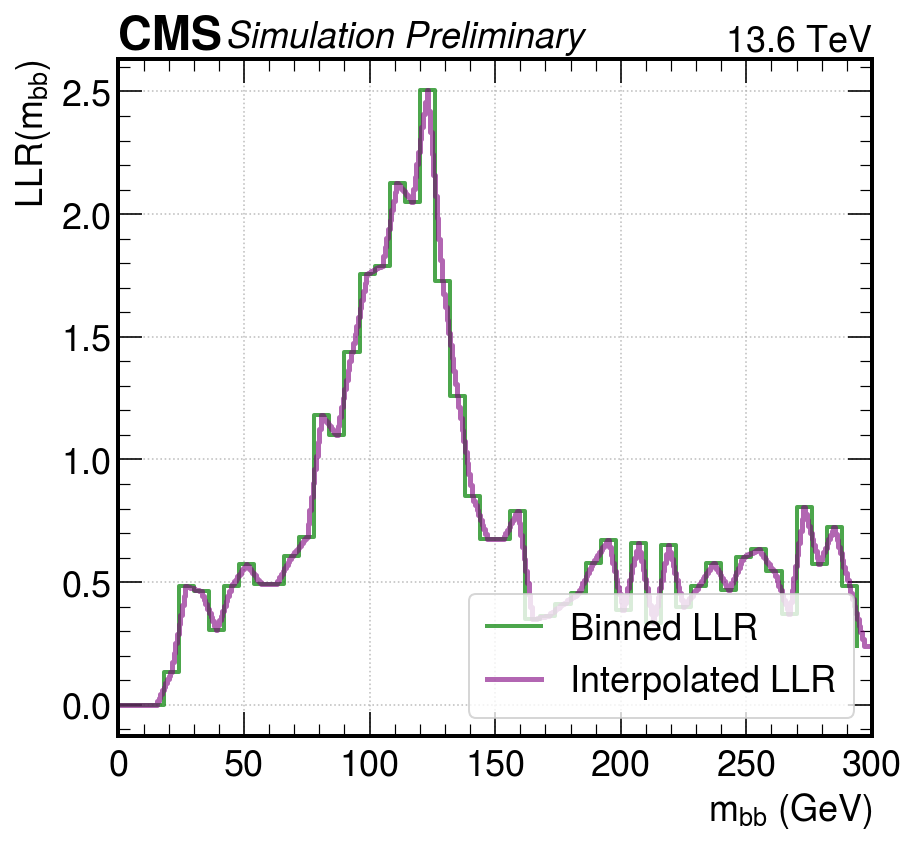

From histograms


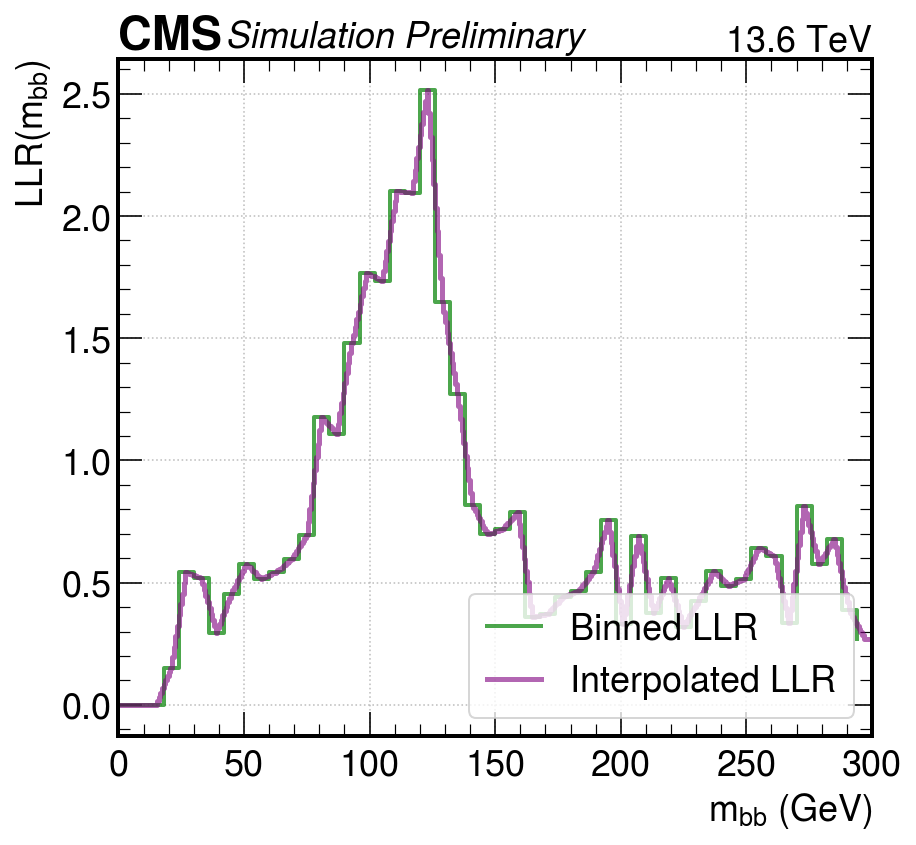

From dsr (branches)


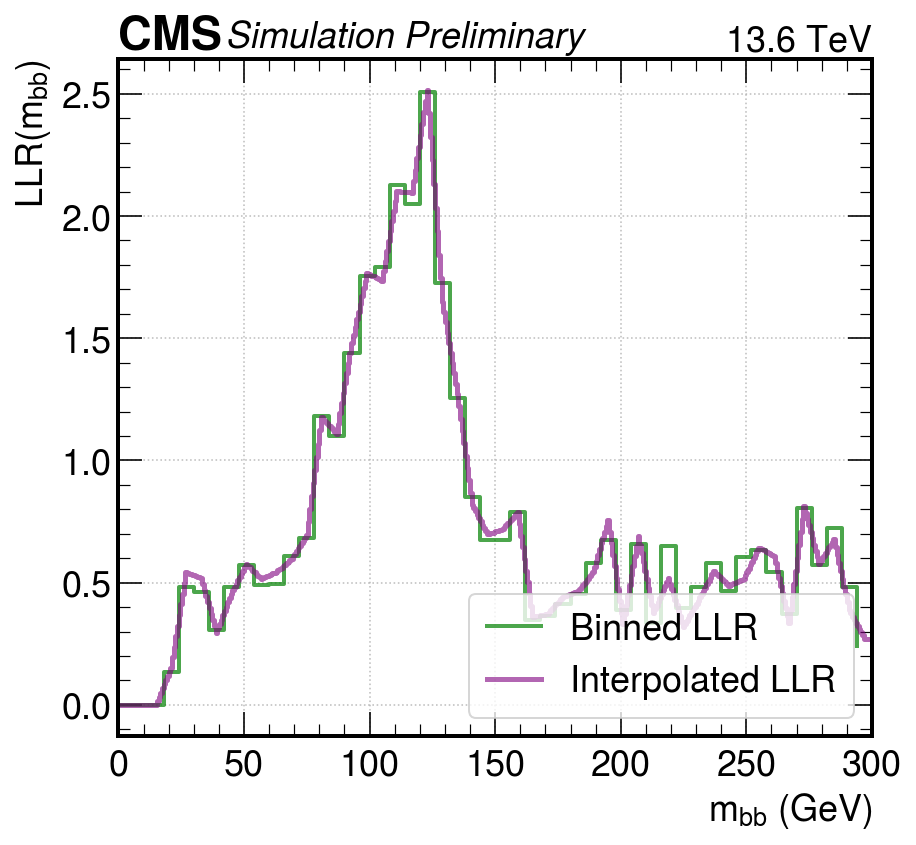

In [13]:
from bamboo_hh_new.utils.histograms import get_total_hist_from_histograms, get_total_hist_from_branches, normalize_hist
from bamboo_hh_new.utils.lr_mapping_from_hists import compute_lr
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Refactoring_Reference/JetTop_even_test_from_RC')
resultsdir = workdir / 'results'

var_name = 'bjets_mbb'
selection = 'SL_4j_resolved'

ref = '_'.join([selection, var_name])

signal_filenames = ['bbWW_sl_2022']
background_filenames = ['tbarWplus_sl_2022']
signal_files = references.get_files(resultsdir, signal_filenames)
background_files = references.get_files(resultsdir, background_filenames)
config = AnalysisConfig(Path('/afs/cern.ch/user/a/anunezde/bamboodev/hh/bamboo_hh_new/config/analysis_DiscStudy.yml'))

print(f"From branches")
signal_hist = get_total_hist_from_branches(signal_files, selection, var_name, config)
background_hist = get_total_hist_from_branches(background_files, selection, var_name, config)
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Refactoring_Reference/JetTop_even_test_from_RC/lr_functions_from_branches.json')
ratio_hist = compute_lr(signal_hist, background_hist)
plot_lr(ratio_hist, mapping_path, f"{ref}_lr", take_log=False)

print(f"From histograms")
signal_hist = get_total_hist_from_histograms(ref, signal_files, config)
background_hist = get_total_hist_from_histograms(ref, background_files, config)
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Refactoring_Reference/JetTop_even_test_from_RC/lr_functions_from_hists.json')
ratio_hist = compute_lr(signal_hist, background_hist)
plot_lr(ratio_hist, mapping_path, f"{ref}_lr", take_log=False)

print(f"From dsr (branches)")
from bamboo_hh_new.utils.lr_mapping_from_dsr import get_total_hist_for_tree
signal_hist = get_total_hist_for_tree(signal_files, selection, var_name, config)
background_hist = get_total_hist_for_tree(background_files, selection, var_name, config)
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Refactoring_Reference/JetTop_even_test_from_RC/lr_functions_from_hists.json')
ratio_hist = compute_lr(signal_hist, background_hist)
plot_lr(ratio_hist, mapping_path, f"{ref}_lr", take_log=False)

From branches


/tmp/anunezde/ipykernel_41910/256248531.py:18: RuntimeWarning: divide by zero encountered in log
  lr_vals = np.log(ratio_vals)


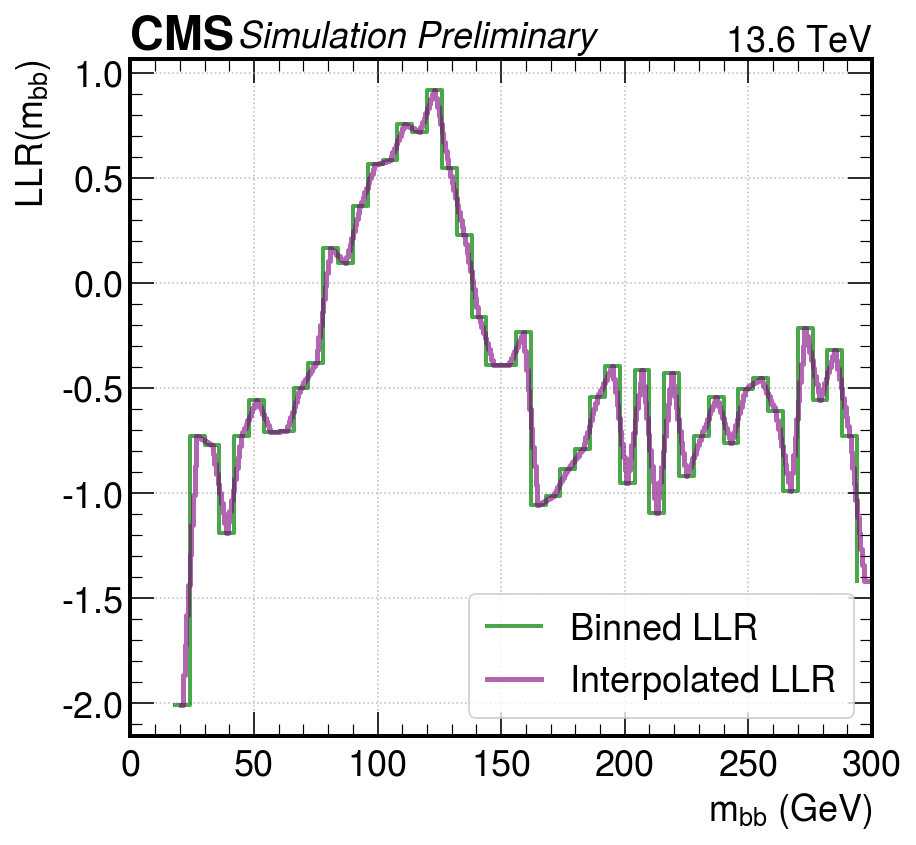

From histograms


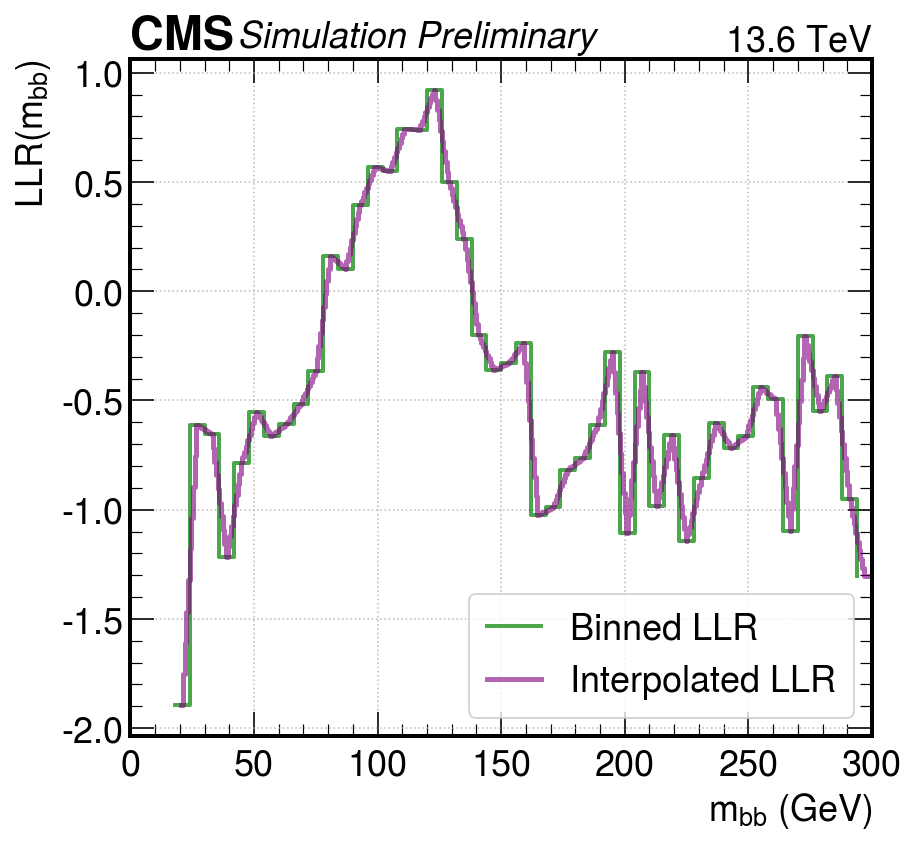

From dsr (branches)


/tmp/anunezde/ipykernel_41910/256248531.py:18: RuntimeWarning: divide by zero encountered in log
  lr_vals = np.log(ratio_vals)


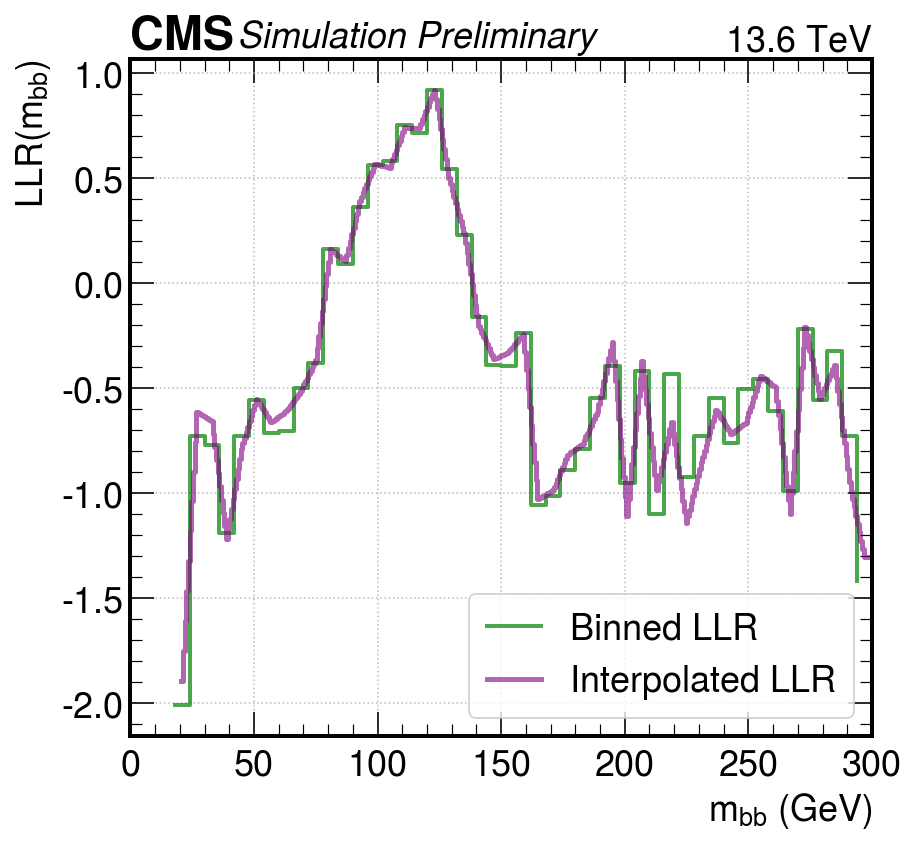

Warning in <TROOT::Append>: Replacing existing TH1: bjets_mbb_bbWW_sl_2022 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: bjets_mbb_bbWW_sl_2022 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: bjets_mbb_tbarWplus_sl_2022 (Potential memory leak).


In [14]:
print(f"From branches")
signal_hist = get_total_hist_from_branches(signal_files, selection, var_name, config)
background_hist = get_total_hist_from_branches(background_files, selection, var_name, config)
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Refactoring_Reference/JetTop_even_test_from_RC/lr_functions_from_branches_log.json')
ratio_hist = compute_lr(signal_hist, background_hist)
plot_lr(ratio_hist, mapping_path, f"{ref}_llr", take_log=True)

print(f"From histograms")
signal_hist = get_total_hist_from_histograms(ref, signal_files, config)
background_hist = get_total_hist_from_histograms(ref, background_files, config)
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Refactoring_Reference/JetTop_even_test_from_RC/lr_functions_from_hists_log.json')
ratio_hist = compute_lr(signal_hist, background_hist)
plot_lr(ratio_hist, mapping_path, f"{ref}_llr", take_log=True)

print(f"From dsr (branches)")
from bamboo_hh_new.utils.lr_mapping_from_dsr import get_total_hist_for_tree
signal_hist = get_total_hist_for_tree(signal_files, selection, var_name, config)
background_hist = get_total_hist_for_tree(background_files, selection, var_name, config)
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Refactoring_Reference/JetTop_even_test_from_RC/lr_functions_from_hists_log.json')
ratio_hist = compute_lr(signal_hist, background_hist)
plot_lr(ratio_hist, mapping_path, f"{ref}_llr", take_log=True)